<a href="https://colab.research.google.com/github/JorgeBuor/Data-Visualization/blob/main/Data_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Name: Jorge Estiven Burgos Ortega
# Course: Data Mining — Universidad de la Costa


---
## Step 0: Import Libraries

In [2]:
# ── Librerías base ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Estilo de gráficas ───────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 110})

---
## Step 1: Load Dataset & Exploratory Analysis

### 1.1 Load the Dataset

The dataset `university_student_data.csv` contains institutional records covering student applications, admissions, enrollment, retention, and satisfaction across multiple academic years and departments.

To load it in Google Colab, use `pd.read_csv()`. If the file is not already in the Colab environment, it can be uploaded manually using `files.upload()` or by mounting Google Drive.

In [3]:
# leer el archivo
df = pd.read_csv('university_student_data.csv')

print(f"Dataset cargado: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()

Dataset cargado: 20 filas x 11 columnas


,Year,Term,Applications,Admitted,Enrolled,Retention Rate (%),Student Satisfaction (%),Engineering Enrolled,Business Enrolled,Arts Enrolled,Science Enrolled
0,2015,Spring,2500,1500,600,85,78,200,150,125,125
1,2015,Fall,2500,1500,600,85,78,200,150,125,125
2,2016,Spring,2600,1550,625,86,79,210,160,130,125
3,2016,Fall,2600,1550,625,86,79,210,160,130,125
4,2017,Spring,2700,1600,650,87,80,225,165,135,125


### 1.2 Column Documentation

The table below describes every column available in the dataset and its meaning within the university study context:

| Column | Type | Description |
|---|---|---|
| `Year` | int | Academic year of the record (2015–2024). |
| `Term` | str | Academic term: **Spring** (first semester) or **Fall** (second semester). |
| `Applications` | int | Total number of admission applications received in that year/term. |
| `Admitted` | int | Number of applicants officially admitted. |
| `Enrolled` | int | Number of students who effectively enrolled after being admitted. |
| `Retention Rate (%)` | float | Percentage of enrolled students who continued their studies in the following term. |
| `Student Satisfaction (%)` | float | Average satisfaction percentage reported by students in institutional surveys. |
| `Engineering Enrolled` | int | Students enrolled in the **Engineering** department. |
| `Business Enrolled` | int | Students enrolled in the **Business** department. |
| `Arts Enrolled` | int | Students enrolled in the **Arts** department. |
| `Science Enrolled` | int | Students enrolled in the **Science** department. |

In [4]:
# ── Tipos de datos y valores nulos ───────────────────────────────────────────
print("=== Tipos de datos ===")
print(df.dtypes)
print("\n=== Valores nulos por columna ===")
print(df.isnull().sum())

=== Tipos de datos ===
Year                         int64
Term                        object
Applications                 int64
Admitted                     int64
Enrolled                     int64
Retention Rate (%)           int64
Student Satisfaction (%)     int64
Engineering Enrolled         int64
Business Enrolled            int64
Arts Enrolled                int64
Science Enrolled             int64
dtype: object

=== Valores nulos por columna ===
Year                        0
Term                        0
Applications                0
Admitted                    0
Enrolled                    0
Retention Rate (%)          0
Student Satisfaction (%)    0
Engineering Enrolled        0
Business Enrolled           0
Arts Enrolled               0
Science Enrolled            0
dtype: int64


In [5]:
# ── Estadísticas descriptivas con gradiente visual ───────────────────────────
df.describe().T.style.background_gradient(cmap='Blues')

,count,mean,std,min,25%,50%,75%,max
Year,20.000000,2019.500000,2.946898,2015.000000,2017.000000,2019.500000,2022.000000,2024.000000
Applications,20.000000,2970.000000,322.163737,2500.000000,2700.000000,2950.000000,3250.000000,3500.000000
Admitted,20.000000,1755.000000,191.187425,1500.000000,1600.000000,1725.000000,1900.000000,2100.000000
Enrolled,20.000000,699.000000,62.903435,600.000000,650.000000,695.000000,750.000000,800.000000
Retention Rate (%),20.000000,87.100000,1.618967,85.000000,86.000000,87.000000,88.000000,90.000000
Student Satisfaction (%),20.000000,82.600000,3.118704,78.000000,80.000000,82.500000,85.000000,88.000000
Engineering Enrolled,20.000000,248.000000,31.556132,200.000000,225.000000,245.000000,275.000000,300.000000
Business Enrolled,20.000000,184.500000,22.763082,150.000000,165.000000,182.500000,200.000000,225.000000
Arts Enrolled,20.000000,146.500000,15.568186,125.000000,135.000000,142.500000,160.000000,175.000000
Science Enrolled,20.000000,120.000000,8.271702,100.000000,115.000000,122.500000,125.000000,130.000000


In [6]:
# ── Valores únicos en columnas categóricas ───────────────────────────────────
print(f"Años disponibles  : {sorted(df['Year'].unique())}")
print(f"Términos disponibles: {df['Term'].unique().tolist()}")
print(f"\nRegistros por término:")
print(df['Term'].value_counts())

Años disponibles  : [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Términos disponibles: ['Spring', 'Fall']

Registros por término:
Term
Spring    10
Fall      10
Name: count, dtype: int64


---
## Step 2: Exploratory Visualizations

The following visualizations explore the three indicators required by the activity:
1. Retention rate trends over time.
2. Student satisfaction scores by year.
3. Comparison between Spring and Fall terms.

`groupby()` is used to aggregate the data, and `matplotlib` / `seaborn` are used to generate the corresponding plots.

### 2.1 Retention Rate Trends Over Time

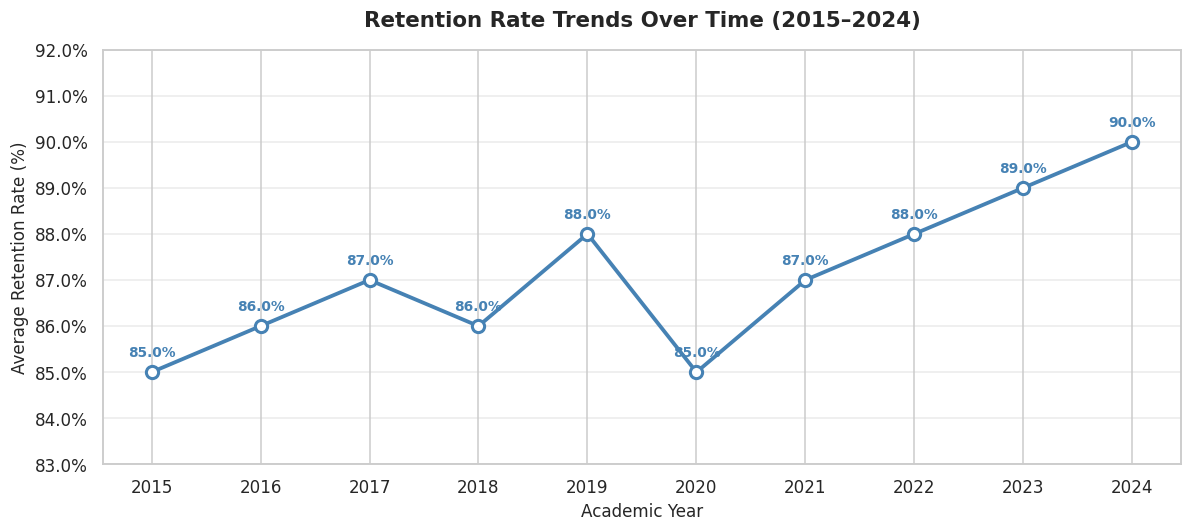

 Year  Avg_Retention
 2015           85.0
 2016           86.0
 2017           87.0
 2018           86.0
 2019           88.0
 2020           85.0
 2021           87.0
 2022           88.0
 2023           89.0
 2024           90.0


In [7]:
# ── Agrupación: tasa de retención promedio por año ───────────────────────────
retention_by_year = (
    df.groupby('Year')['Retention Rate (%)']
    .mean()
    .reset_index()
    .rename(columns={'Retention Rate (%)': 'Avg_Retention'})
)

# ── Gráfico de línea ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(
    retention_by_year['Year'],
    retention_by_year['Avg_Retention'],
    marker='o', linewidth=2.5, color='steelblue',
    markersize=8, markerfacecolor='white', markeredgewidth=2
)

# Anotaciones de valor en cada punto
for _, row in retention_by_year.iterrows():
    ax.annotate(
        f"{row['Avg_Retention']:.1f}%",
        xy=(row['Year'], row['Avg_Retention']),
        xytext=(0, 10), textcoords='offset points',
        ha='center', fontsize=9, color='steelblue', fontweight='bold'
    )

ax.set_title('Retention Rate Trends Over Time (2015–2024)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Academic Year', fontsize=11)
ax.set_ylabel('Average Retention Rate (%)', fontsize=11)
ax.set_xticks(retention_by_year['Year'])
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax.set_ylim(83, 92)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

print(retention_by_year.to_string(index=False))

### 2.2 Student Satisfaction Scores by Year

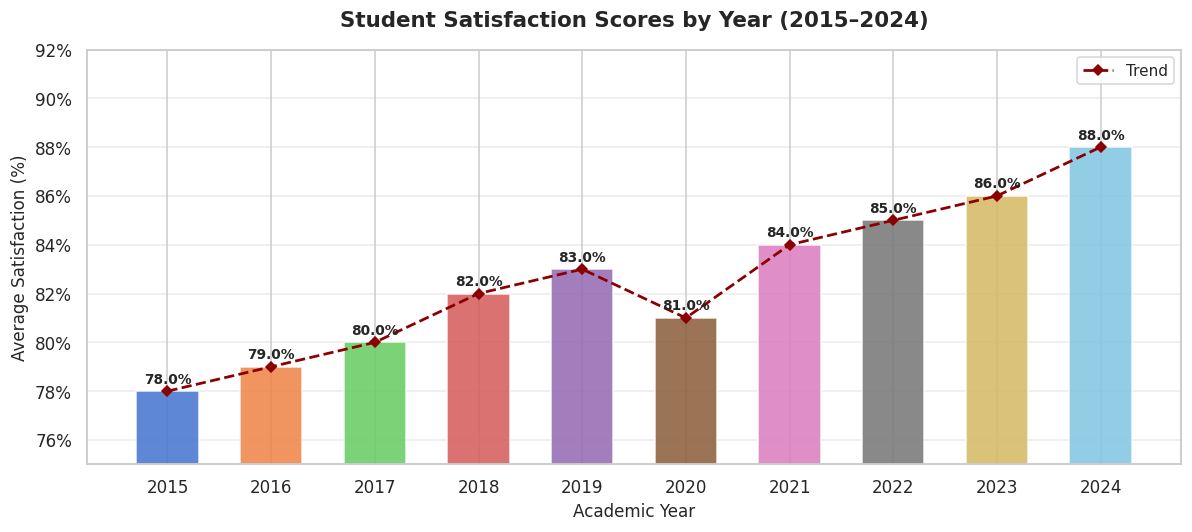

 Year  Avg_Satisfaction
 2015              78.0
 2016              79.0
 2017              80.0
 2018              82.0
 2019              83.0
 2020              81.0
 2021              84.0
 2022              85.0
 2023              86.0
 2024              88.0


In [8]:
# ── Agrupación: satisfacción promedio por año ────────────────────────────────
satisfaction_by_year = (
    df.groupby('Year')['Student Satisfaction (%)']
    .mean()
    .reset_index()
    .rename(columns={'Student Satisfaction (%)': 'Avg_Satisfaction'})
)

# ── Bar chart + línea de tendencia ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

bars = ax.bar(
    satisfaction_by_year['Year'],
    satisfaction_by_year['Avg_Satisfaction'],
    color=sns.color_palette('muted', len(satisfaction_by_year)),
    edgecolor='white', width=0.6, alpha=0.88
)

# Línea de tendencia sobre las barras
ax.plot(
    satisfaction_by_year['Year'],
    satisfaction_by_year['Avg_Satisfaction'],
    color='darkred', linewidth=1.8, linestyle='--',
    marker='D', markersize=5, label='Trend'
)

# Etiquetas en barras
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f"{bar.get_height():.1f}%",
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

ax.set_title('Student Satisfaction Scores by Year (2015–2024)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Academic Year', fontsize=11)
ax.set_ylabel('Average Satisfaction (%)', fontsize=11)
ax.set_xticks(satisfaction_by_year['Year'])
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.set_ylim(75, 92)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

print(satisfaction_by_year.to_string(index=False))

### 2.3 Comparison Between Spring and Fall Terms

In [9]:
# ── Agrupación: métricas clave por término ───────────────────────────────────
term_comparison = (
    df.groupby('Term')[['Applications', 'Enrolled',
                         'Retention Rate (%)', 'Student Satisfaction (%)']]
    .mean()
    .reset_index()
)

print("=== Promedio de métricas por término ===")
print(term_comparison.to_string(index=False))

=== Promedio de métricas por término ===
  Term  Applications  Enrolled  Retention Rate (%)  Student Satisfaction (%)
  Fall        2970.0     699.0                87.1                      82.6
Spring        2970.0     699.0                87.1                      82.6


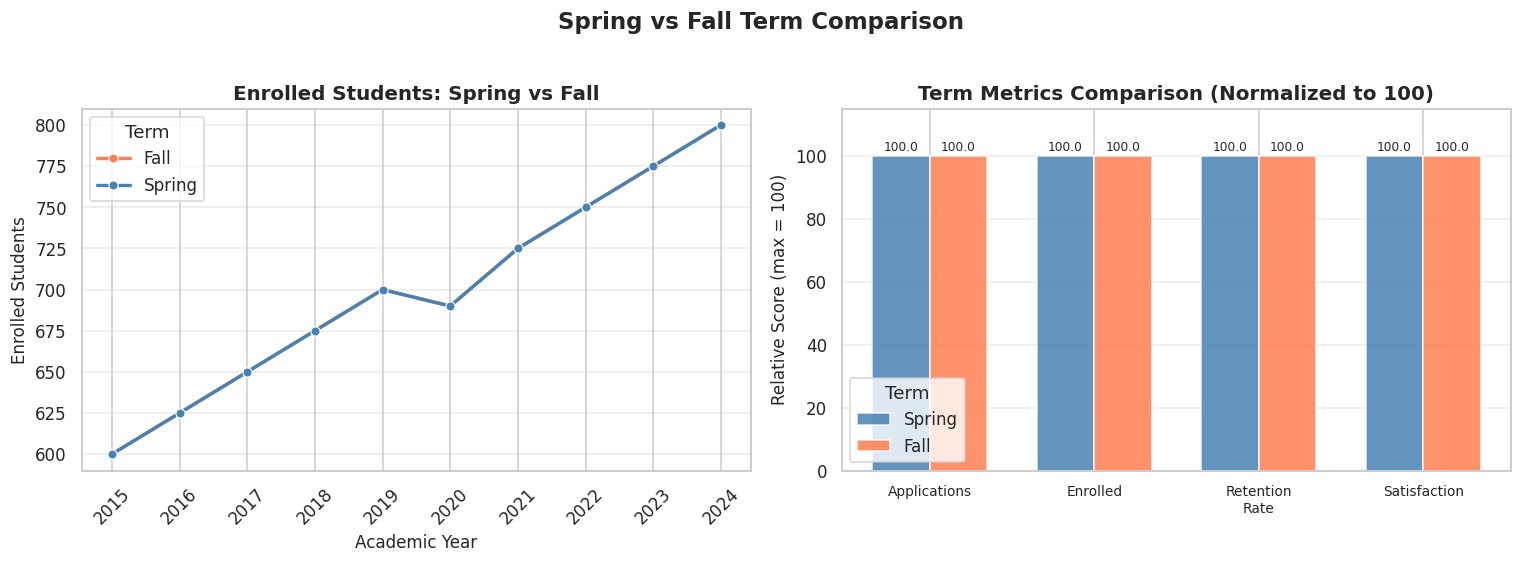

In [10]:
# ── Agrupación: matriculados por año y término ───────────────────────────────
enrolled_term = (
    df.groupby(['Year', 'Term'])['Enrolled']
    .sum()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Panel izquierdo: sns.lineplot de matriculados por término ────────────────
sns.lineplot(
    data=enrolled_term, x='Year', y='Enrolled',
    hue='Term', marker='o', linewidth=2.2,
    palette={'Spring': 'steelblue', 'Fall': 'coral'},
    ax=axes[0]
)
axes[0].set_title('Enrolled Students: Spring vs Fall', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Academic Year', fontsize=11)
axes[0].set_ylabel('Enrolled Students', fontsize=11)
axes[0].set_xticks(df['Year'].unique())
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.4)
axes[0].legend(title='Term')

# ── Panel derecho: bar chart comparativo normalizado a 100 ───────────────────
metrics_cols = ['Applications', 'Enrolled', 'Retention Rate (%)', 'Student Satisfaction (%)']
x     = np.arange(len(metrics_cols))
width = 0.35

sv   = term_comparison[term_comparison['Term'] == 'Spring'][metrics_cols].values[0]
fv   = term_comparison[term_comparison['Term'] == 'Fall'][metrics_cols].values[0]
maxv = np.maximum(sv, fv)
sn   = sv / maxv * 100
fn   = fv / maxv * 100

b1 = axes[1].bar(x - width/2, sn, width, label='Spring',
                 color='steelblue', alpha=0.85, edgecolor='white')
b2 = axes[1].bar(x + width/2, fn, width, label='Fall',
                 color='coral',    alpha=0.85, edgecolor='white')

# Etiquetas sobre cada barra
for bar in list(b1) + list(b2):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{bar.get_height():.1f}",
        ha='center', va='bottom', fontsize=8
    )

axes[1].set_title('Term Metrics Comparison (Normalized to 100)', fontsize=13, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Applications', 'Enrolled', 'Retention\nRate', 'Satisfaction'], fontsize=9)
axes[1].set_ylabel('Relative Score (max = 100)', fontsize=11)
axes[1].set_ylim(0, 115)
axes[1].legend(title='Term')
axes[1].grid(axis='y', alpha=0.4)

plt.suptitle('Spring vs Fall Term Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 2.4 Enrollment Breakdown by Department

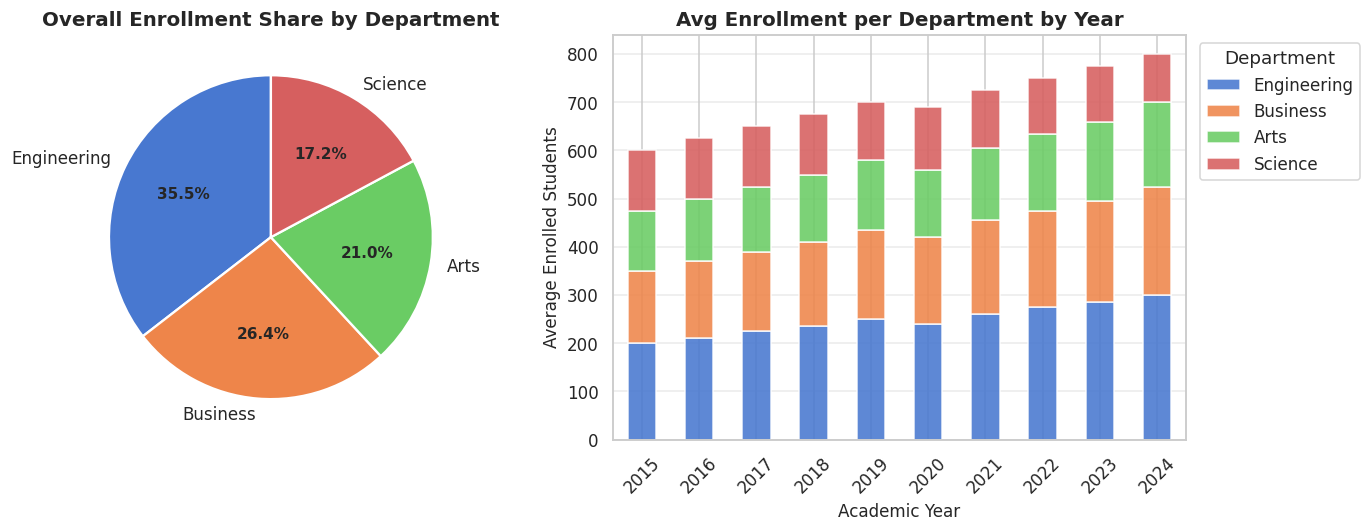

In [11]:
# ── Columnas y etiquetas de departamentos ────────────────────────────────────
dept_cols  = ['Engineering Enrolled', 'Business Enrolled',
              'Arts Enrolled', 'Science Enrolled']
dept_names = ['Engineering', 'Business', 'Arts', 'Science']

# ── Totales globales y promedio anual por departamento ───────────────────────
dept_totals  = df[dept_cols].sum()
dept_by_year = df.groupby('Year')[dept_cols].mean()
dept_by_year.columns = dept_names

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors_pie = sns.color_palette('muted', 4)

# ── Pie chart: participación global por departamento ─────────────────────────
wedges, texts, autotexts = axes[0].pie(
    dept_totals,
    labels=dept_names,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors_pie,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
axes[0].set_title('Overall Enrollment Share by Department', fontsize=13, fontweight='bold')

# ── Stacked bar: evolución de matriculados por departamento y año ────────────
dept_by_year.plot(
    kind='bar', stacked=True,
    color=colors_pie, edgecolor='white',
    alpha=0.88, ax=axes[1]
)
axes[1].set_title('Avg Enrollment per Department by Year', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Academic Year', fontsize=11)
axes[1].set_ylabel('Average Enrolled Students', fontsize=11)
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Department', bbox_to_anchor=(1.01, 1), loc='upper left')
axes[1].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

### 2.5 Key Findings

Based on the visualizations above, the following trends can be highlighted:

- **Retention Rate:** shows a consistent upward trend from 85% in 2015 to 90% in 2024, with a slight dip in 2020 likely associated with the impact of the pandemic. This suggests that institutional retention policies have been progressively effective.
- **Student Satisfaction:** grew steadily from 78% to 88% over the analyzed period, with the steepest increase occurring between 2020 and 2022, reflecting improvements in the student experience despite pandemic disruptions.
- **Spring vs Fall:** both terms show virtually identical figures across all metrics, indicating strong institutional consistency between periods. Neither term holds a significant advantage in retention or satisfaction.
- **Departments:** Engineering leads overall enrollment with approximately 38% of total students, followed by Business (26%), Arts (20%), and Science (16%). Science enrollment shows a slight downward trend in recent years.